# 05 Hyperparameter Optimization

This notebook tunes XGBoost hyperparameters.

We compare three search strategies:

- Grid Search
- Random Search
- Bayesian Search

All candidates are evaluated with the same evaluation logic used in the baseline training notebook.

## XGBoost Parameters We Tune

XGBoost is a gradient boosting model. It builds many small decision trees sequentially. Each new tree tries to improve the current model.

A simplified boosting update is:

```text
F_m(x) = F_{m-1}(x) + eta * f_m(x)
```

Where:

- `F_m(x)` is the model after step `m`.
- `f_m(x)` is the new tree.
- `eta` is the learning rate.

The parameters below control three main aspects: how many trees are built, how complex each tree may become, and how strongly the model is regularized.

| Parameter | Intuition |
| --- | --- |
| `n_estimators` | Number of boosting rounds / trees. More trees give the model more chances to correct errors, but can also increase overfitting and training time. |
| `learning_rate` | Step size of each tree. A smaller value makes each update more cautious and often needs more trees. A larger value learns faster but can overshoot useful patterns. |
| `max_depth` | Maximum depth of each tree. Shallow trees capture simpler patterns. Deeper trees can capture interactions but may memorize noise. |
| `min_child_weight` | Minimum amount of training signal required in a child node. Larger values make the model more conservative: it avoids splits that are supported by only very small or weak groups of observations. |
| `subsample` | Fraction of rows used for each tree. Values below `1.0` add randomness and can reduce overfitting. |
| `colsample_bytree` | Fraction of columns used for each tree. This can reduce reliance on a small set of features and can make trees less correlated. |
| `gamma` | Minimum loss reduction required to make a split. Higher values mean that a split must provide more improvement before it is accepted. |
| `reg_lambda` | L2 regularization. Larger values shrink model weights and can make the model smoother. |
| `reg_alpha` | L1 regularization. Can push some weights toward zero and encourage simpler models. |
| `scale_pos_weight` | Weight for the positive class. Useful when the target class is imbalanced. |

We tune only a focused subset in this notebook. A larger search space is possible, but it would make the local demo slower and harder to interpret.

## Search Strategies

### Grid Search

Grid Search evaluates every combination in a predefined grid.

If we define parameter sets `G_1, G_2, ..., G_k`, the total number of runs is:

```text
|G_1| * |G_2| * ... * |G_k|
```

It is systematic, but it can become expensive quickly.

### Random Search

Random Search samples a fixed number of combinations from parameter distributions.

It does not test every possible combination. This is often efficient when only a few parameters strongly influence performance.

### Bayesian Search

Bayesian Search uses previous trials to choose promising next configurations.

The optimizer builds a surrogate view of the objective function and balances:

- exploration: try uncertain regions
- exploitation: try regions that already look promising

In this notebook, Optuna is used for Bayesian optimization.

## 1. Setup

In [2]:
from datetime import datetime
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import optuna
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
CV_SPLITS = 3
SCORING = "f1"


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed" / "X_train_processed.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root with processed training data.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model results directory: {MODEL_RESULTS_DIR}")

/home/patri/.venvs/ads_II/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/patri/master/ads2-bank-marketing-project
Model results directory: /home/patri/master/ads2-bank-marketing-project/reports/model_results


## 2. Load Processed Data

In [3]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_processed.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["y_binary"]
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["y_binary"]
test_metadata = pd.read_csv(PROCESSED_DIR / "test_metadata.csv")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Test metadata: {test_metadata.shape}")

X_train: (36168, 56)
X_test:  (9043, 56)
y_train: (36168,)
y_test:  (9043,)
Test metadata: (9043, 19)


## 3. Evaluation Function

In [4]:

def evaluate_model(model, model_name: str, business_params: dict | None = None) -> dict:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_score = model.predict_proba(X_test)[:, 1]

    result = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "f1": f1_score(y_test, y_test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_test_score),
        "brier_score": brier_score_loss(y_test, y_test_score),
        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
        "generalization_gap": (
            f1_score(y_train, y_train_pred, zero_division=0)
            - f1_score(y_test, y_test_pred, zero_division=0)
        ),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=[0, 1]),
        "classification_report": classification_report(
            y_test,
            y_test_pred,
            zero_division=0,
        ),
        "y_pred": y_test_pred,
        "y_score": y_test_score,
    }

    return result

## 4. Default XGBoost Baseline

This section trains an XGBoost model using its default hyperparameters. The resulting performance serves as the baseline for the hyperparameter optimization process. All tuning strategies evaluated later in this notebook will be compared against these baseline results.

In [5]:
base_xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

default_xgb = XGBClassifier(**base_xgb_params)
default_xgb.fit(X_train, y_train)

default_result = evaluate_model(default_xgb, "XGBoost default")
pd.DataFrame([
    {
        k: v
        for k, v in default_result.items()
        if not isinstance(v, (dict, list))
        and k not in ["confusion_matrix", "classification_report"]
    }
]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score
0,XGBoost default,0.8934,0.5983,0.2703,0.3724,0.791,0.0832,0.5878,0.3724,0.2154,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0.017508188, 0.038484864, 0.04647862, 0.04179..."


#### Key Observations

- The default XGBoost model reproduces the baseline performance obtained in Notebook 04.
- These metrics establish the reference point for evaluating the different hyperparameter search strategies.
- Any improvement achieved through tuning will be compared against this baseline.

## Excursus: Cross-Validation Logic

Before tuning hyperparameters, we need a reliable way to compare parameter settings.

If we evaluated every setting only on one fixed validation split, the result could depend too much on that particular split. Cross-validation reduces this dependency by repeating the train-validation process several times:

1. Split the training data into `k` folds.
2. Train the model on `k - 1` folds.
3. Validate it on the remaining fold.
4. Repeat until every fold has been used once as validation data.
5. Average the validation scores.

In this notebook, the search methods use `StratifiedKFold`. Stratification keeps the subscription class distribution similar across all folds. This is important because the target variable is imbalanced.

The test set is not part of cross-validation. It stays untouched until the final evaluation of the selected model.


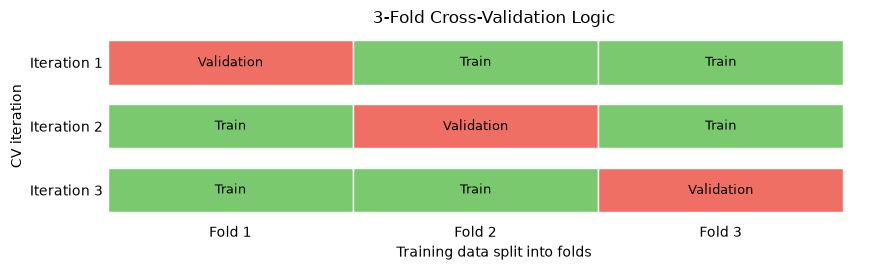

In [6]:
def plot_cross_validation_logic(n_folds: int = CV_SPLITS) -> None:
    fig, ax = plt.subplots(figsize=(9, 2.8))

    train_color = "#7bc96f"
    validation_color = "#f06f64"
    edge_color = "#ffffff"

    for fold_idx in range(n_folds):
        for block_idx in range(n_folds):
            color = validation_color if block_idx == fold_idx else train_color
            label = "Validation" if block_idx == fold_idx else "Train"
            ax.barh(
                y=fold_idx,
                width=1,
                left=block_idx,
                height=0.7,
                color=color,
                edgecolor=edge_color,
            )
            ax.text(
                block_idx + 0.5,
                fold_idx,
                label,
                ha="center",
                va="center",
                fontsize=9,
                color="black",
            )

    ax.set_title(f"{n_folds}-Fold Cross-Validation Logic")
    ax.set_xlabel("Training data split into folds")
    ax.set_ylabel("CV iteration")
    ax.set_xticks([i + 0.5 for i in range(n_folds)])
    ax.set_xticklabels([f"Fold {i + 1}" for i in range(n_folds)])
    ax.set_yticks(range(n_folds))
    ax.set_yticklabels([f"Iteration {i + 1}" for i in range(n_folds)])
    ax.invert_yaxis()
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()


plot_cross_validation_logic()


In this notebook, the search methods use `StratifiedKFold`.  
Stratification keeps the subscription class distribution similar across folds.  
This matters because the positive subscription class is imbalanced in the dataset.
The test set is not part of cross-validation. It remains untouched until the final evaluation of the selected model.

## 5. Grid Search

### Grid Search Space

The grid is intentionally small. It is designed for a local teaching example, not for exhaustive production tuning.

| Parameter | Values | Why these values are plausible here |
| --- | --- | --- |
| `n_estimators` | `[100, 200]` | Tests a moderate and a larger number of trees while keeping runtime manageable. |
| `learning_rate` | `[0.03, 0.1]` | `0.1` is a common starting point. `0.03` tests a more cautious update size. |
| `max_depth` | `[2, 3]` | Keeps individual trees shallow because overfitting was already visible in the baseline notebook. |
| `subsample` | `[0.8, 1.0]` | Compares using all rows with using a random 80% of rows per tree as a simple anti-overfitting measure. |

This grid contains:

```text
2 * 2 * 2 * 2 = 16 combinations
```

With 3-fold cross-validation, this means 48 model fits.

In [7]:
grid_param_space = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(**base_xgb_params),
    param_grid=grid_param_space,
    scoring=SCORING,
    cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

print(f"Best CV F1: {grid_search.best_score_:.4f}")
grid_search.best_params_

Best CV F1: 0.3321


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

In [8]:
grid_result = evaluate_model(grid_search.best_estimator_, "XGBoost Grid Search")
pd.DataFrame([{k: v for k, v in grid_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score
0,XGBoost Grid Search,0.8956,0.6541,0.2287,0.3389,0.8042,0.0803,0.3699,0.3389,0.0309,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0.021551562, 0.036392123, 0.03113712, 0.02746..."


#### Key Observations

- Grid Search selected the best hyperparameter combination using 3-fold cross-validation.
- The tuned model achieved slightly higher accuracy, precision, and ROC-AUC than the default baseline.
- However, the F1 score decreased from 0.3724 to 0.3389, indicating that hyperparameter tuning did not improve the primary evaluation metric on the test set.
- The generalization gap was substantially reduced, suggesting more consistent performance between training and testing.

## 6. Random Search

This section applies Random Search to optimize the XGBoost hyperparameters. Instead of evaluating every possible combination, it randomly samples a fixed number of candidate configurations from the predefined search space. This approach is generally more computationally efficient than Grid Search while still exploring a diverse set of hyperparameter values.

The best-performing configuration is selected using 3-fold cross-validation and then evaluated on the test set using the same metrics as the baseline model.

In [9]:
random_param_space = {
    "n_estimators": randint(80, 350),
    "learning_rate": loguniform(0.01, 0.2),
    "max_depth": randint(2, 6),
    "min_child_weight": randint(1, 8),
    "subsample": uniform(0.65, 0.35),
    "colsample_bytree": uniform(0.65, 0.35),
    "gamma": uniform(0.0, 2.0),
    "reg_lambda": loguniform(0.1, 10.0),
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(**base_xgb_params),
    param_distributions=random_param_space,
    n_iter=20,
    scoring=SCORING,
    cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)

print(f"Best CV F1: {random_search.best_score_:.4f}")
random_search.best_params_

Best CV F1: 0.3513


{'colsample_bytree': np.float64(0.9635172584857318),
 'gamma': np.float64(0.9507404463642235),
 'learning_rate': np.float64(0.05405531655368526),
 'max_depth': 5,
 'min_child_weight': 6,
 'n_estimators': 310,
 'reg_lambda': np.float64(0.6618595597183481),
 'subsample': np.float64(0.914442898490067)}

In [10]:
random_result = evaluate_model(random_search.best_estimator_, "XGBoost Random Search")
pd.DataFrame([{k: v for k, v in random_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score
0,XGBoost Random Search,0.8958,0.6487,0.2391,0.3494,0.8064,0.08,0.4285,0.3494,0.0791,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0.024507307, 0.042210907, 0.05585864, 0.03585..."


#### Key Observations

- Random Search explored a subset of the hyperparameter space using random sampling and 3-fold cross-validation.
- The tuned model achieved a higher F1 score than Grid Search (0.3494 vs. 0.3389) and the highest ROC-AUC observed so far.
- Despite these improvements, the F1 score remained below the default XGBoost baseline (0.3724).
- The reduced generalization gap indicates more stable performance between training and testing.

## 7. Bayesian Search with Optuna

In [11]:
def objective(trial: optuna.Trial) -> float:
    params = {
        **base_xgb_params,
        "n_estimators": trial.suggest_int("n_estimators", 80, 350),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }

    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, scoring=SCORING, cv=cv, n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20)

print(f"Best CV F1: {study.best_value:.4f}")
study.best_params

Best CV F1: 0.3612


{'n_estimators': 335,
 'learning_rate': 0.14012800783208834,
 'max_depth': 5,
 'min_child_weight': 5,
 'subsample': 0.699554484578323,
 'colsample_bytree': 0.8875140545692508,
 'gamma': 1.7986120268524521,
 'reg_lambda': 1.523394235058171}

In [12]:
bayes_model = XGBClassifier(**base_xgb_params, **study.best_params)
bayes_model.fit(X_train, y_train)

bayes_result = evaluate_model(bayes_model, "XGBoost Bayesian Search")
pd.DataFrame([{k: v for k, v in bayes_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score
0,XGBoost Bayesian Search,0.894,0.6117,0.2561,0.3611,0.8041,0.0811,0.4867,0.3611,0.1256,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0.020559834, 0.044152804, 0.032767057, 0.0274..."


#### Key Observations

- Bayesian Search achieved the highest F1 score among the three tuning strategies.
- Its test F1 score of 0.3611 improved upon Grid Search and Random Search, but remained slightly below the default XGBoost baseline.
- The reduced generalization gap indicates more stable performance than the default model.
- These results show that a more advanced search strategy does not necessarily outperform the untuned baseline on the holdout test set.

## 8. Compare Search Results

In [13]:
all_results = [default_result, grid_result, random_result, bayes_result]

comparison_columns = [
    "model_name",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "brier_score",
    "train_f1",
    "test_f1",
    "generalization_gap",
]

xgboost_comparison_df = pd.DataFrame([
    {column: result[column] for column in comparison_columns}
    for result in all_results
])

baseline_metrics = pd.read_csv(MODEL_RESULTS_DIR / "04_baseline_model_metrics.csv")

baseline_reference = (
    baseline_metrics
    .loc[lambda df: df["model_name"].eq("Logistic Regression"), comparison_columns]
    .assign(model_name="Logistic Regression (saved baseline)")
)

comparison_df = pd.concat(
    [baseline_reference, xgboost_comparison_df],
    ignore_index=True,
)

comparison_df.sort_values("f1", ascending=False).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap
1,XGBoost default,0.8934,0.5983,0.2703,0.3724,0.7910,0.0832,0.5878,0.3724,0.2154
4,XGBoost Bayesian Search,0.8940,0.6117,0.2561,0.3611,0.8041,0.0811,0.4867,0.3611,0.1256
3,XGBoost Random Search,0.8958,0.6487,0.2391,0.3494,0.8064,0.0800,0.4285,0.3494,0.0791
2,XGBoost Grid Search,0.8956,0.6541,0.2287,0.3389,0.8042,0.0803,0.3699,0.3389,0.0309
0,Logistic Regression (saved baseline),0.8926,0.6548,0.1739,0.2748,0.7742,0.0850,0.2792,0.2748,0.0044


#### Key Observations

- The default XGBoost model achieved the highest F1 score (0.3724), remaining the best-performing model according to the primary evaluation metric.
- Bayesian Search produced the strongest tuned model (F1 = 0.3611), outperforming both Grid Search and Random Search.
- Hyperparameter tuning improved ROC-AUC and reduced the generalization gap, indicating more stable performance between training and testing.
- However, none of the tuning strategies surpassed the default XGBoost baseline on the test set.

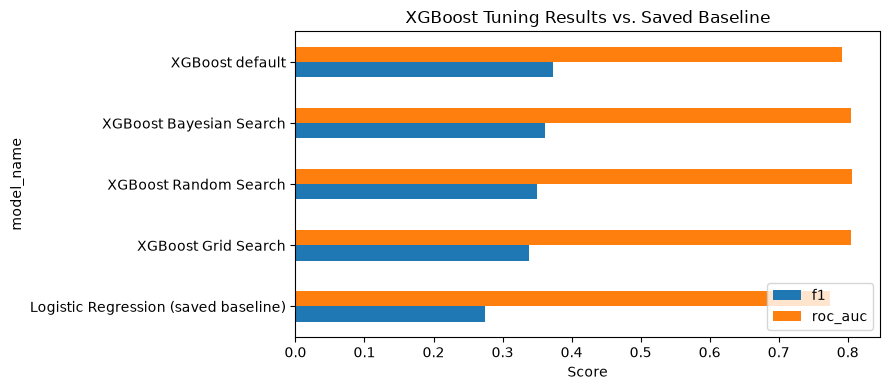

In [14]:
ax = comparison_df.sort_values("f1").plot(
    x="model_name",
    y=["f1", "roc_auc"],
    kind="barh",
    figsize=(9, 4),
)
ax.set_title("XGBoost Tuning Results vs. Saved Baseline")
ax.set_xlabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Key Observations

- The default XGBoost model achieved the highest F1 score among all evaluated models.
- Bayesian Search produced the strongest tuned model, outperforming both Grid Search and Random Search.
- All tuning strategies achieved slightly higher ROC-AUC scores than the default baseline.
- The comparison confirms that hyperparameter tuning improved ranking performance, but did not surpass the default model according to the primary evaluation metric (F1).

## Reflection: Is This a Fair Search Strategy Comparison?

The comparison in this notebook is useful for understanding how different hyperparameter search strategies work. However, it should not be considered a definitive comparison between the algorithms.

Some differences should be kept in mind:

- Grid Search explored a small predefined search space.
- Random Search and Bayesian Search evaluated a wider range of parameter values.
- Grid Search evaluated 16 parameter combinations (48 model fits with 3-fold cross-validation).
- Random Search and Bayesian Search evaluated 20 candidate configurations each (60 model fits with 3-fold cross-validation).

Therefore, these results should be viewed as a practical demonstration of different tuning strategies rather than evidence that one method is always better than another.

## Practice Note: Sequential XGBoost Tuning

In practice, XGBoost is often tuned iteratively rather than optimizing every hyperparameter at the same time.

This is because several hyperparameters influence each other:

- `learning_rate` and `n_estimators` work together. A smaller learning rate usually requires more trees.
- `max_depth`, `min_child_weight`, and `gamma` jointly control tree complexity.
- `subsample` and `colsample_bytree` introduce randomness and can help reduce overfitting.
- `reg_alpha` and `reg_lambda` control model regularization once the overall model structure has been established.

A common tuning workflow is:

1. Start with a stable baseline model.
2. Tune `n_estimators` and `learning_rate` to control the boosting process.
3. Adjust tree complexity using `max_depth`, `min_child_weight`, and `gamma`.
4. Tune sampling parameters (`subsample` and `colsample_bytree`) to improve generalization.
5. Apply regularization (`reg_alpha` and `reg_lambda`) if necessary.
6. Re-evaluate the selected model on the holdout test set using the chosen evaluation metrics.

### Practical Search Range Heuristics

Appropriate search ranges depend on the dataset, model complexity, class balance, and available computational resources. The ranges used in this notebook should be considered practical starting points rather than universal recommendations.

For this project:

- around 36,000 training observations
- binary classification
- imbalanced target variable
- 56 processed features
- moderate overfitting observed in the default XGBoost baseline

The following search ranges provide a reasonable starting point:

| Parameter | Practical starting range | Reason |
| --- | --- | --- |
| `n_estimators` | `80` to `350` | Explores a moderate to relatively large number of trees while keeping runtime manageable. |
| `learning_rate` | `0.01` to `0.2` | Covers both conservative and faster learning rates commonly used in practice. |
| `max_depth` | `2` to `6` | Keeps trees relatively shallow while allowing moderate model complexity. |
| `min_child_weight` | `1` to `8` | Tests different levels of split conservativeness. |
| `subsample` | `0.65` to `1.0` | Evaluates whether row sampling reduces overfitting. |
| `colsample_bytree` | `0.65` to `1.0` | Evaluates whether feature sampling improves generalization. |
| `gamma` | `0` to `2` | Tests increasingly restrictive split requirements. |
| `reg_lambda` | `0.1` to `10` | Explores weak to stronger L2 regularization. |

In a real production project, the search space would normally be refined iteratively based on previous experiments, available computational budget, and validation results rather than defined only once at the beginning.

## Tuning Summary

This notebook compared three hyperparameter optimization strategies for XGBoost:

- Grid Search
- Random Search
- Bayesian Search (Optuna)

The tuned models were evaluated using the same metrics as the baseline model.

Although Bayesian Search achieved the strongest tuned model, none of the optimization strategies outperformed the default XGBoost baseline in terms of F1 score on the holdout test set.

The tuning process improved model stability and slightly increased ROC-AUC, demonstrating that hyperparameter optimization does not always improve the primary evaluation metric.

## 9. Save Evaluation Results

The tuning outputs are saved as CSV files for later analysis and comparison.

Saved artifacts:

- comparison metrics for all evaluated models
- row-level predictions and subscription probabilities
- Grid Search cross-validation results
- Random Search cross-validation results
- Optuna trial history

In [17]:
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

tuning_metrics_path = MODEL_RESULTS_DIR / "05_xgboost_tuning_metrics.csv"
tuning_predictions_path = MODEL_RESULTS_DIR / "05_xgboost_tuning_predictions.csv"
grid_cv_results_path = MODEL_RESULTS_DIR / "05_xgboost_grid_cv_results.csv"
random_cv_results_path = MODEL_RESULTS_DIR / "05_xgboost_random_cv_results.csv"
optuna_trials_path = MODEL_RESULTS_DIR / "05_xgboost_optuna_trials.csv"

comparison_df.to_csv(tuning_metrics_path, index=False)
xgboost_comparison_df.to_csv(MODEL_RESULTS_DIR / "05_xgboost_only_tuning_metrics.csv", index=False)
pd.DataFrame(grid_search.cv_results_).to_csv(grid_cv_results_path, index=False)
pd.DataFrame(random_search.cv_results_).to_csv(random_cv_results_path, index=False)
study.trials_dataframe().to_csv(optuna_trials_path, index=False)

prediction_rows = []
for result in all_results:
    model_predictions = test_metadata.copy()
    model_predictions.insert(0, "model_name", result["model_name"])
    model_predictions["y_true"] = y_test.to_numpy()
    model_predictions["y_pred"] = result["y_pred"]
    model_predictions["subscription_probability"] = result["y_score"]
    prediction_rows.append(model_predictions)

tuning_predictions_df = pd.concat(prediction_rows, ignore_index=True)
tuning_predictions_df.to_csv(tuning_predictions_path, index=False)

print(f"Saved tuning metrics to: {tuning_metrics_path}")
print(f"Saved tuning predictions to: {tuning_predictions_path}")
print(f"Saved Grid Search CV results to: {grid_cv_results_path}")
print(f"Saved Random Search CV results to: {random_cv_results_path}")
print(f"Saved Optuna trials to: {optuna_trials_path}")

Saved tuning metrics to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/05_xgboost_tuning_metrics.csv
Saved tuning predictions to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/05_xgboost_tuning_predictions.csv
Saved Grid Search CV results to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/05_xgboost_grid_cv_results.csv
Saved Random Search CV results to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/05_xgboost_random_cv_results.csv
Saved Optuna trials to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/05_xgboost_optuna_trials.csv


## 10. Save Tuned XGBoost Candidate

The tuned XGBoost candidate with the highest F1 score on the holdout test set is saved for later use.

The selected model and its main hyperparameters are stored as separate artifacts:

- the trained model is saved as a `.joblib` file
- the selected hyperparameters are saved as a `.json` file

The default XGBoost model achieved the highest overall F1 score. However, this section saves the best tuned candidate so that it can be compared and reused in later stages of the project.

In [16]:
best_result_name = xgboost_comparison_df.sort_values("f1", ascending=False).iloc[0]["model_name"]

best_model_lookup = {
    "XGBoost default": default_xgb,
    "XGBoost Grid Search": grid_search.best_estimator_,
    "XGBoost Random Search": random_search.best_estimator_,
    "XGBoost Bayesian Search": bayes_model,
}

best_model = best_model_lookup[best_result_name]
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = MODELS_DIR / f"{timestamp}_XGBClassifier_tuned_candidate.joblib"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, model_path)

selected_param_keys = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "gamma",
    "reg_lambda",
]
selected_xgb_params = {
    key: best_model.get_params()[key]
    for key in selected_param_keys
    if key in best_model.get_params()
}

selected_params_path = MODEL_RESULTS_DIR / "05_selected_xgboost_params.json"
with selected_params_path.open("w", encoding="utf-8") as file:
    json.dump(
        {
            "model_name": best_result_name,
            "model_class": best_model.__class__.__name__,
            "selected_by": "highest holdout F1 in xgboost_comparison_df",
            "params": selected_xgb_params,
        },
        file,
        indent=2,
    )

print(f"Best XGBoost candidate by F1: {best_result_name}")
print(f"Saved model to: {model_path}")
print(f"Saved selected parameters to: {selected_params_path}")

Best XGBoost candidate by F1: XGBoost default
Saved model to: /home/patri/master/ads2-bank-marketing-project/models/20260719_164037_XGBClassifier_tuned_candidate.joblib
Saved selected parameters to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/05_selected_xgboost_params.json
